<a href="https://colab.research.google.com/github/Sr1n1vas0504/SMART-SUSPENSION-SYSTEM/blob/main/Smart_Suspension_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
uploaded = files.upload()

Saving final_ARX_clean_dataset.xlsx to final_ARX_clean_dataset.xlsx


Dataset Shape: (23685, 37)
Columns: Index(['RoadDepth_m', 'RoadWidth_m', 'Area_m2', 'AspectRatio', 'SeverityIndex',
       'ImpactVelocity_mps', 'ImpactForce_N', 'Distance_m', 'TimeToImpact_s',
       'VehicleMass_kg', 'SprungMass_kg', 'UnsprungMass_kg',
       'VehicleSpeed_mps', 'CG_height_m', 'Wheelbase_m', 'TireRadius_m',
       'SpringStiffness_Npm', 'TireStiffness_Npm', 'DampingRatio',
       'NaturalFrequency_radps', 'SuspensionTravelLimit_m',
       'RelativeVelocity_mps', 'BodyVelocity_mps', 'WheelVelocity_mps',
       'BodyAcceleration_mps2', 'WheelAcceleration_mps2',
       'SuspensionDeflection_previous', 'PreviousRoadInput',
       'PreviousDamperCoefficient', 'PreviousDamperSetting',
       'PreviousSpringSetting', 'Optimal_DamperCoefficient_previous',
       'Optimal_DamperForce_previous', 'Optimal_DamperDisplacement_previous',
       'Optimal_DamperCoefficient', 'Optimal_DamperForce',
       'Optimal_DamperDisplacement'],
      dtype='object')
R² Score: 0.98275325846604

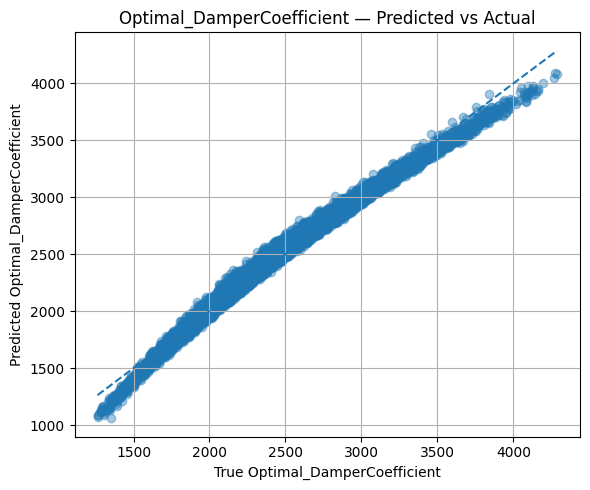





Graph 2: Optimal_DamperForce — Predicted vs Actual



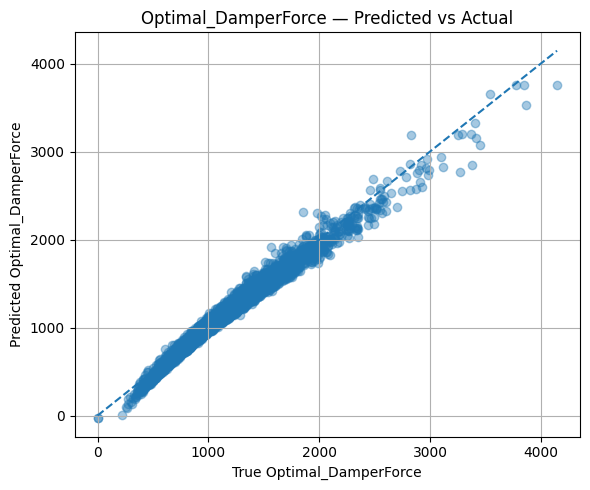





Graph 3: Optimal_DamperDisplacement — Predicted vs Actual



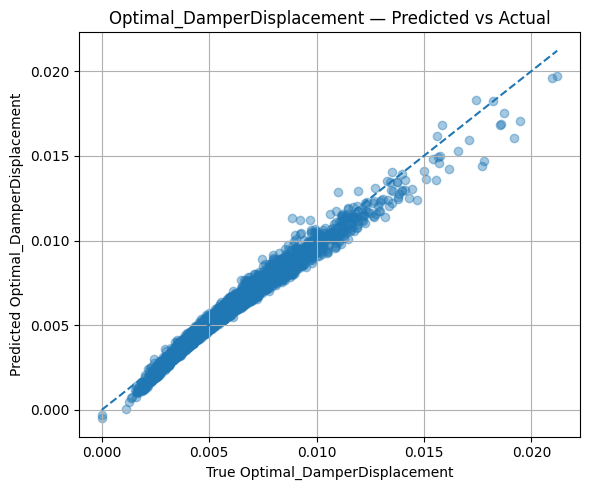




Predicted Optimal Suspension Settings:
Damper Coefficient: 1715.2751268327997
Damper Force: 658.0371522188266
Damper Displacement: 0.002957797438630233


In [8]:
# SMART SUSPENSION ARX ML MODEL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. LOAD DATASET
data = pd.read_excel("final_ARX_clean_dataset.xlsx")
print("Dataset Shape:", data.shape)
print("Columns:", data.columns)

# 2. DEFINE INPUTS (ARX Structure)
X = data[[
'RoadDepth_m','RoadWidth_m','Area_m2','AspectRatio','SeverityIndex',
'ImpactVelocity_mps','ImpactForce_N','Distance_m','TimeToImpact_s',
'VehicleMass_kg','SprungMass_kg','UnsprungMass_kg','VehicleSpeed_mps',
'CG_height_m','Wheelbase_m','TireRadius_m',
'SpringStiffness_Npm','TireStiffness_Npm',
'DampingRatio','NaturalFrequency_radps',
'SuspensionTravelLimit_m',
'RelativeVelocity_mps','BodyVelocity_mps','WheelVelocity_mps',
'BodyAcceleration_mps2','WheelAcceleration_mps2',
'SuspensionDeflection_previous',
'PreviousRoadInput',
'PreviousDamperCoefficient',
'PreviousDamperSetting',
'PreviousSpringSetting',
'Optimal_DamperCoefficient_previous',
'Optimal_DamperForce_previous',
'Optimal_DamperDisplacement_previous'
]]

# 3. DEFINE OUTPUTS
y = data[[
'Optimal_DamperCoefficient',
'Optimal_DamperForce',
'Optimal_DamperDisplacement'
]]

# 4. TRAIN TEST SPLIT (70-30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# 5. NORMALIZE DATA
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 6. TRAIN ARX
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

# 7. PREDICTIONS
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# 8. EVALUATION
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("===================================")
print("R² Score:", r2)
print("RMSE:", rmse)
print("===================================")

# 9. PLOT PREDICTION vs TRUE


import matplotlib.pyplot as plt

y_columns = [
    'Optimal_DamperCoefficient',
    'Optimal_DamperForce',
    'Optimal_DamperDisplacement'
]

for i, col in enumerate(y_columns):

    print("\n" + "="*60)
    print(f"Graph {i+1}: {col} — Predicted vs Actual")
    print("="*60 + "\n")

    plt.figure(figsize=(6,5))  # Same size for all

    plt.scatter(
        y_test.iloc[:, i],
        y_pred[:, i],
        alpha=0.4
    )

    # Perfect prediction line
    min_val = y_test.iloc[:, i].min()
    max_val = y_test.iloc[:, i].max()

    plt.plot([min_val, max_val],
             [min_val, max_val],
             linestyle='--',
             linewidth=1.5)

    plt.xlabel("True " + col)
    plt.ylabel("Predicted " + col)
    plt.title(f"{col} — Predicted vs Actual")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Add spacing between graphs
    print("\n\n")

# 10. TEST ON NEW INPUT
sample_input = X_test.iloc[0:1]
sample_input_scaled = scaler_X.transform(sample_input)
prediction_scaled = model.predict(sample_input_scaled)
prediction = scaler_y.inverse_transform(prediction_scaled)
print("Predicted Optimal Suspension Settings:")
print("Damper Coefficient:", prediction[0][0])
print("Damper Force:", prediction[0][1])
print("Damper Displacement:", prediction[0][2])